In [1]:
# Standard library imports
import os
import random
import sys

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure matplotlib
plt.style.use('../fig.style')
figsize = (8,4)

# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)
    
# Project imports
from src import get_alphabet
from src.features import get_pairwise_features
from src.fixers.fix_pairwise_model import fix_pairwise_model
from src._test_gauge_fixing import _test_gauge_fixing
from src.seq_embedder import SeqEmbedder


In [2]:
# Plot parameters
def plot_pairwise_thetas(theta_series, fixed_theta_series):
    for order in range(3)[::-1]:
        ix = [len(orbit)==order for orbit,_ in theta_series.index]
        plt.scatter(theta_series[ix], fixed_theta_series[ix], marker='.', label=f'{order=}')
    plt.xlabel('theta_series')
    plt.ylabel('fixed_theta_series')
    plt.legend()
    print(f'features match: {all(theta_series.index == fixed_theta_series.index)}')

N=3,121
000 f=2.212182 	 f_fixed=2.212182
001 f=42.310046 	 f_fixed=42.310046
002 f=-19.773499 	 f_fixed=-19.773499
003 f=-3.879462 	 f_fixed=-3.879462
004 f=-0.405145 	 f_fixed=-0.405145
005 f=11.815709 	 f_fixed=11.815709
006 f=-4.880119 	 f_fixed=-4.880119
007 f=-16.447557 	 f_fixed=-16.447557
008 f=2.358593 	 f_fixed=2.358593
009 f=2.012788 	 f_fixed=2.012788
Tested 10 random sequences; all seqs passed.
features match: True


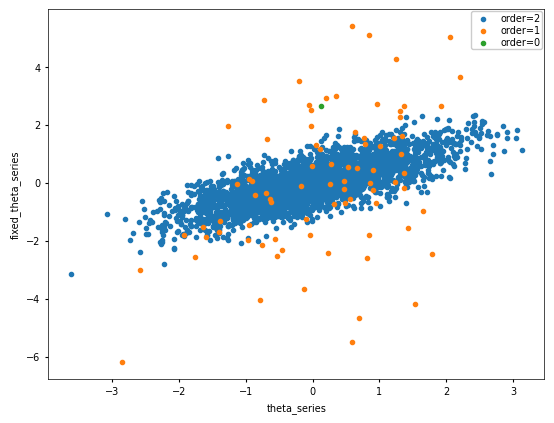

In [3]:
L = 20
alphabet = get_alphabet('dna')
alpha = len(alphabet)
features = get_pairwise_features(L=L, alphabet=alphabet)
N = len(features)
print(f'{N=:,}')

# Create theta_series
theta_series = pd.Series(index=features,
                         data=np.random.normal(size=N))



# Fix gauge
fixed_theta_series = fix_pairwise_model(theta=theta_series,
                                        L=L, 
                                        alphabet=alphabet,
                                        gauge='zero-sum')

# Create embedder
embedder = SeqEmbedder(features=features, 
                       L=L)

# Test result
_test_gauge_fixing(theta_series=theta_series, 
                   theta_fixed_series=fixed_theta_series, 
                   L=L, 
                   alphabet=alphabet, 
                   embedder=embedder,
                   num_trials=10)

# Plot resulting parameters
plot_pairwise_thetas(theta_series=theta_series, fixed_theta_series=fixed_theta_series)

In [4]:
from src.evaluate_model_on_seqs import evaluate_model_on_seqs
from itertools import product

random_seqs = [''.join(random.choices(alphabet, k=L)) for _ in range(100)]
evaluate_model_on_seqs(theta=theta_series,
                       seqs=random_seqs,
                       embedder=embedder)

array([ 22.27815485,  -1.58829489,  -5.65559514,  29.06303675,
        12.96894209, -14.40222831,  -5.46100567,  13.61453389,
       -14.63822998,   7.0526415 ,  21.50978824, -13.5710056 ,
        13.80298929,   5.50330981,  -7.57697188, -12.91860462,
        20.94412392, -12.75480257,  13.7352909 ,  11.27208837,
        37.25319641,   3.30542463,   3.5976197 ,  -6.41394399,
         3.01719448,  15.10601261,  22.78217685,  -5.55891099,
        -5.19460947,   8.77413202,  13.93941544, -16.37468237,
        -2.54524353,  -0.69059926,  15.88735727,   2.83650783,
        17.42209834,  -5.19842441,  -7.82457443,  -6.85595776,
         8.12462005,  -3.15233433,  22.46920312,  -0.67502826,
        15.56164235,   3.1808737 ,  32.88667377, -12.86790501,
       -16.77682046, -11.80119259,  -5.60583954,  -5.47278101,
        -1.68292932,  18.04181552,   9.55979044,  -0.7398505 ,
        26.92821344,  -3.4896605 ,  38.42884303,  27.89876393,
       -10.5444922 ,  -6.4936487 ,   8.77127849,   4.91